# Arbeitspaket (AP) 2: Datenbeschaffung, Datenaufbereitung & explorative Datenanalyse

### Persönliche Angaben (bitte ergänzen) und Prüfungsregeln

<table>
  <tr><td>Vorname:</td><td></td></tr>
  <tr><td>Nachname:</td><td></td></tr>
  <tr><td>Immatrikulationsnummer:</td><td></td></tr>
  <tr><td>Modul:</td><td>Data Science</td></tr>
  <tr><td>Prüfungsdatum / Raum / Zeit:</td><td>[TT.MM.2026] / Raum: [anpassen] / [hh:mm – hh:mm]</td></tr>
  <tr><td>Erlaubte Hilfsmittel:</td><td>Open Book, Eigener Computer, Internet-Zugang</td></tr>
  <tr><td>Nicht erlaubt:</td><td>Nicht erlaubt ist der systematische Einsatz von generativer KI (z.B. Copilot, ChatGPT, Claude, Google's «Übersicht mit KI») für das Lösen der Aufgaben sowie beliebige Formen von Kommunikation oder Kollaboration mit anderen Menschen.</td></tr>
  <tr><td>Technische Probleme:</td><td>Wenden Sie sich bei technischen Problemen umgehend an die Prüfungsaufsicht.</td></tr>
</table>

## Bewertungskriterien

**(max. erreichbare Punkte: 40)**

<table>
  <thead>
    <tr><th>Teil</th><th>Thema</th><th>Aufgaben</th><th>Punkte</th></tr>
  </thead>
  <tbody>
    <tr><td>A</td><td>Konzeptfragen: Datenaufbereitung &amp; explorative Datenanalyse</td><td>A1–A3</td><td>12</td></tr>
    <tr><td>B</td><td>Fehleranalyse Python-Code (Shop-Daten)</td><td>B1–B2</td><td>16</td></tr>
    <tr><td>C</td><td>Python-Code schreiben: Web Scraping, Datenaufbereitung &amp; EDA</td><td>C1–C3</td><td>12</td></tr>
    <tr><td><b>Total</b></td><td></td><td><b>8 Aufgaben</b></td><td><b>40</b></td></tr>
  </tbody>
</table>

### Bewertungsschema

Jede Aufgabe wird für sich und **als Ganzes** bewertet. Ihre Punktzahl steht in der Überschrift.

<table>
  <thead>
    <tr><th>Kategorie</th><th>Beschreibung</th><th>Bewertung</th><th>4 Pkt</th><th>8 Pkt</th></tr>
  </thead>
  <tbody>
    <tr><td>Korrekt</td><td>Vollständig und fachlich einwandfrei: Antwort bzw. Begründung korrekt und nachvollziehbar; bei Code-Aufgaben liefert der Python-Code das richtige Ergebnis</td><td>100%</td><td>4</td><td>8</td></tr>
    <tr><td>Minimale Mängel</td><td>Kleine Fehler (z.B. falsche Sortierung, fehlende Rundung, fehlende Achsenbeschriftung) oder Begründung ungenau bzw. unvollständig</td><td>75%</td><td>3</td><td>6</td></tr>
    <tr><td>Mittlere Mängel</td><td>Grössere Fehler (z.B. fehlende Spalten, falsche Filterung) oder Begründung fehlt bzw. ist fachlich falsch</td><td>50%</td><td>2</td><td>4</td></tr>
    <tr><td>Gravierende Mängel</td><td>Problem bzw. Ansatz erkennbar, aber Lösung oder Schlussfolgerung im Kern falsch (z.B. Problem richtig benannt, aber falsch behoben; im Code: ungeeigneter Lösungsweg wie falscher Join-Typ, falsche Tabelle oder falsche Datei)</td><td>25%</td><td>1</td><td>2</td></tr>
    <tr><td>Nicht lauffähig / nicht sinnvoll</td><td>Antwort fehlt, Code nicht lauffähig (z.B. Syntaxfehler) oder kein Bezug zur Aufgabe</td><td>0%</td><td>0</td><td>0</td></tr>
  </tbody>
</table>

Treffen mehrere Mängel zusammen, zählt der schwerste. Alternative, fachlich korrekte Lösungswege werden ebenfalls als korrekt gewertet.

## Hinweise zu den Daten

Alle Daten stammen vom **fiktiven** Schweizer Online-Shop «PhoneMarkt» und liegen **lokal** im gleichen Verzeichnis wie dieses Notebook. Für die Prüfung ist **kein Internetzugriff** auf Websites oder APIs nötig.

<table>
  <thead>
    <tr><th>Datei</th><th>Format</th><th>Inhalt</th></tr>
  </thead>
  <tbody>
    <tr><td><code>html/shop_page_1.html</code> … <code>shop_page_3.html</code></td><td>HTML</td><td>Gespeicherte Produktlisten-Seiten (3 Seiten mit Paginierung)</td></tr>
    <tr><td><code>html/product_detail.html</code></td><td>HTML</td><td>Gespeicherte Detailseite eines Geräts (Preisverlauf, technische Daten)</td></tr>
    <tr><td><code>reviews.json</code></td><td>JSON</td><td>Gespeicherte Antwort der Reviews-API: Liste mit Kundenbewertungen pro <code>product_id</code></td></tr>
    <tr><td><code>smartphones_clean.csv</code></td><td>CSV</td><td>Aufbereitete Shop-Daten: Formate vereinheitlicht, Duplikate entfernt — <b>inhaltlich nicht geprüft</b></td></tr>
  </tbody>
</table>

Die Spaltenbeschreibungen finden Sie im Sheet **«Description»**, die Datenquellen im Sheet **«Data Sources»** der beiliegenden Datei `smartphone_data.xlsx`. Die HTML-Dateien können Sie zur Ansicht auch im Browser oder als Text im Editor öffnen.

**Antworten auf Konzeptfragen** und **Begründungen** tragen Sie bitte direkt in die vorgesehenen Markdown-Zellen ein.

## Setup (wird nicht bewertet)

In [1]:
# Libraries
import os
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Get current working directory
print(os.getcwd())

/workspaces/DS_HS2026_LNW/DS_HS2026_LNW_I_Examples/AP02


### Produktlisten-Seiten scrapen → `df_raw`

Der folgende Code liest die drei gespeicherten Produktlisten-Seiten mit BeautifulSoup ein (analog zur Übung `skipass_data.ipynb`). Jede Produktkarte (`<div class="product-card">`) wird zu einer Zeile im Data Frame `df_raw`. Die Werte werden **als Text** übernommen (Spalten mit Endung `_raw`) und noch nicht bereinigt.

In [2]:
# Initialize list for the extracted rows
rows = []

# Loop over the three listing pages
for page in [1, 2, 3]:

    # Read html from file
    with open(f'html/shop_page_{page}.html', 'r', encoding='utf-8') as file:
        html_content = file.read()

    # Parse the HTML content
    soup = BeautifulSoup(html_content, 'html.parser')

    # Locate the product cards and extract values
    for card in soup.select('div.product-card'):
        row_data = [card['data-product-id'],
                    card.select('span.brand')[0].get_text().replace('\xa0', '').strip(),
                    card.select('span.model')[0].get_text().replace('\xa0', '').strip(),
                    card.select('li.storage')[0].get_text().replace('\xa0', '').strip(),
                    card.select('li.color')[0].get_text().replace('\xa0', '').strip(),
                    card.select('li.screen')[0].get_text().replace('\xa0', '').strip(),
                    card.select('li.battery')[0].get_text().replace('\xa0', '').strip(),
                    card.select('span.price')[0].get_text().replace('\xa0', '').strip(),
                    card.select('span.availability')[0].get_text().replace('\xa0', '').strip()]
        rows.append(row_data)

# Create a DataFrame
df_raw = pd.DataFrame(rows, columns=['product_id', 'brand', 'model', 'storage_raw', 'color',
                                     'screen_raw', 'battery_raw', 'price_raw', 'availability'])

# Show dimensions and first rows
print('Number of rows and columns:', df_raw.shape)
df_raw.head()

Number of rows and columns: (148, 9)


,product_id,brand,model,storage_raw,color,screen_raw,battery_raw,price_raw,availability
0,PM-10001,Xiaomi,Redmi Note 14 Pro 5G,256GB,Midnight Black,"6.67"" Display",5'110mAh,CHF 299.–,Sofort lieferbar
1,PM-10002,OnePlus,OnePlus 13,256GB,Arctic Dawn,"6.82"" Display",6'000mAh,CHF 899.–,Lieferbar in 2–5 Tagen
2,PM-10003,Google,Pixel 10 Pro,512GB,Obsidian,"6.3"" Display",4'870mAh,CHF 1'249.–,Sofort lieferbar
3,PM-10004,Samsung,Galaxy A36 5G,128GB,Awesome Lavender,"6.7"" Display",5'000mAh,CHF 339.–,Sofort lieferbar
4,PM-10005,Samsung,Galaxy Z Fold7,1TB,Jetblack,"8.0"" Display",4'400mAh,Preis auf Anfrage,Vorbestellung


### Aufbereitete Shop-Daten laden → `df_clean`

In [3]:
# Import data from csv to pandas dataframe named 'df_clean'
df_clean = pd.read_csv('smartphones_clean.csv')

# Show dimensions and first rows
print('Number of rows and columns:', df_clean.shape)
df_clean.head()

Number of rows and columns: (142, 9)


,product_id,brand,model,storage_gb,color,screen_inch,battery_mah,price_chf,availability
0,PM-10001,Xiaomi,Redmi Note 14 Pro 5G,256,Midnight Black,6.67,5110,299.0,Sofort lieferbar
1,PM-10002,OnePlus,OnePlus 13,256,Arctic Dawn,6.82,6000,899.0,Lieferbar in 2–5 Tagen
2,PM-10003,Google,Pixel 10 Pro,512,Obsidian,6.30,4870,1249.0,Sofort lieferbar
3,PM-10004,Samsung,Galaxy A36 5G,128,Awesome Lavender,6.70,5000,339.0,Sofort lieferbar
4,PM-10005,Samsung,Galaxy Z Fold7,1024,Jetblack,8.00,4400,NaN,Vorbestellung


> **Hinweis:** Alle Aufgaben sind voneinander unabhängig. Verändern Sie `df_raw` und `df_clean` bitte nicht direkt, sondern arbeiten Sie in jeder Aufgabe mit einem eigenen Data Frame (z.B. `df_B1`, `df_C2`).

---

<div style="background-color:#2E4057; color:white; padding:16px 24px; border-radius:6px; font-size:18px; margin-top:8px;">
&#9654;&nbsp; <strong>Ab hier beginnt die bewertete Prüfung — 40 Punkte</strong><br>
<span style="font-size:15px; font-weight:normal;">Tragen Sie Ihre Antworten direkt in die vorgesehenen Zellen ein und führen Sie alle Code-Zellen aus.</span>
</div>

---
## Teil A – Konzeptfragen (12 Punkte)

*Antworten ohne Bezug zu den Shop-Daten von «PhoneMarkt» werden nicht gewertet.*

### A1 (4 Punkte)

Bei 8 der 142 Geräte zeigt der Shop statt eines Preises den Text «Preis auf Anfrage». Laut Shop-Betreiber wird der Preis ausgeblendet, wenn er eine interne Preisschwelle übersteigt.

a) Um welchen Mechanismus fehlender Werte handelt es sich (MCAR, MAR oder MNAR)? Begründen Sie.

b) Ein Analyst entfernt diese 8 Geräte mit `dropna()` und berichtet anschliessend den durchschnittlichen Gerätepreis des Shops. Welchen Effekt hat das Entfernen auf das Ergebnis?

**Ihre Antwort:**

a) **MNAR:** Ob der Preis fehlt, hängt vom Preis selbst ab — er wird ausgeblendet, wenn er über der Preisschwelle liegt.

b) Es fehlen gerade die teuersten Geräte (Galaxy Z Fold7 und Pixel 10 Pro Fold mit 512 GB bzw. 1 TB). Der Durchschnittspreis wird deshalb **zu tief** ausgewiesen (verzerrt).

> **Nicht Teil der Antwort** — Bezug zu Folien bzw. Übungen
>
> *Bezug: Folien Woche 4 Teil II, S. 11 (MCAR, MAR, MNAR; «If removed, the result will be biased»).*

### A2 (4 Punkte)

Für die Spalte `price_chf` in `smartphones_clean.csv` liefert pandas folgendes Ergebnis:

```
df_clean['price_chf'].describe()          df_clean['price_chf'].skew()
count      134.00                          9.19
mean       992.89
std       1126.48
min        159.00
25%        479.00
50%        899.00
75%       1199.00
max      12990.00
```

Beschreiben Sie die Verteilung der Preise anhand dieser Kennzahlen. Welches Lagemass eignet sich besser, um den «typischen» Gerätepreis zu berichten, und warum? Nennen Sie eine geeignete Grafik, um Ihre Einschätzung zu überprüfen.

**Ihre Antwort:**

Die Preise sind **rechtsschief**: Die Schiefe ist positiv (9.19), der Mittelwert (992.89) liegt über dem Median (899.00), und das Maximum (12'990) ist ein extremer Ausreisser.

Der **Median** ist besser geeignet, weil er von Ausreissern kaum beeinflusst wird.

Geeignete Grafik: **Histogramm** oder **Boxplot**.

> **Nicht Teil der Antwort** — Bezug zu Folien bzw. Übungen
>
> *Bezug: Folien Woche 5, S. 14 (Mittelwert/Median), S. 18–19 (Schiefe, Faustregel Mittelwert vs. Median), S. 29–32 (Boxplot, Histogramm).*

### A3 (4 Punkte)

Ein Kollege verbindet die Shop-Daten mit den Kundenbewertungen aus `reviews.json` und berechnet die Korrelation zwischen `price_chf` und `avg_score` (Durchschnitt der Kundenbewertungen, 1–5 Sterne):

```
df[['price_chf', 'avg_score']].corr()     # Ergebnis: r = 0.34
```

Er folgert: *«Preis und Kundenzufriedenheit hängen kaum zusammen.»*

Nennen und begründen Sie **zwei** fachliche Einwände gegen diese Vorgehensweise bzw. Schlussfolgerung.

**Ihre Antwort:**

1. **Keine Grafik:** Kennzahlen allein können irreführend sein (Anscombe's Quartett). Zuerst sollte ein Scatter Plot erstellt werden.
2. **Ausreisser:** Der Preis von CHF 12'990 verfälscht die Korrelation (ohne ihn: r = 0.76).
3. **Korrelation ≠ Kausalität:** Eine Korrelation sagt nichts über Ursache und Wirkung aus.

> **Nicht Teil der Antwort** — Bezug zu Folien bzw. Übungen
>
> *Bezug: Folien Woche 5, S. 12 (Anscombe's Quartett), S. 25 und S. 41 (Korrelation und Kausalität); Folien Woche 4 Teil II, S. 13 (Ausreisser).*

---
## Teil B – Fehleranalyse Python-Code (16 Punkte)

*Jeder Code läuft fehlerfrei durch, liefert aber ein falsches oder irreführendes Ergebnis. Die tatsächlichen Ergebnisse sind angegeben.*

### B1 (8 Punkte)

**Ziel:** Kennzahlen für das Shop-Sortiment aus den gescrapten Rohdaten `df_raw`: Anzahl Geräte, Anzahl Geräte ohne Preisangabe und Median-Preis in CHF.

```python
# Select columns for the analysis
df_B1 = df_raw[['product_id', 'brand', 'model', 'storage_raw', 'color', 'price_raw']]

# Extract numerical values from price_raw
price = []
for i in df_B1['price_raw']:
    d1 = re.findall(r"\d+", i)
    try:
        d2 = int(d1[0])
    except:
        d2 = None
    price.append(d2)

# Save as new variable in the pandas data frame
df_B1['price_chf'] = pd.Series(price, dtype="Int64")

# Show key figures
print('Anzahl Geräte:            ', df_B1.shape[0])
print('Anzahl ohne Preisangabe:  ', df_B1['price_chf'].isnull().sum())
print('Median-Preis (CHF):       ', df_B1['price_chf'].median())
```

Tatsächliches Ergebnis:

```
Anzahl Geräte:             148
Anzahl ohne Preisangabe:   8
Median-Preis (CHF):        314.0
```

Der Shop gibt auf jeder Seite an, dass er **142 Artikel** führt. Beispiele für Werte in `price_raw`: `CHF 899.–`, `CHF 1'249.–`, `Preis auf Anfrage`.

**Aufgabe:** Schreiben Sie den korrigierten Code in die Zelle «Korrigierter Code» (die Kommentare des ursprünglichen Codes sind als Gerüst vorgegeben), sodass die Kennzahlen stimmen. Begründen Sie jede Änderung gegenüber dem ursprünglichen Code.

**Begründung der Änderungen:**

1. **Duplikate entfernen:** Es gibt Duplikate (148 statt 142 Geräte), weil sich die Seiten überlappen. `drop_duplicates()` entfernt sie, `reset_index(drop=True)` nummeriert den Index neu.
2. **Ganze Zahl übernehmen:** Bei `CHF 1'249.–` liefert `d1[0]` nur die `1`, weil das Apostroph die Zahl trennt. `''.join(d1)` fügt die Teile zu `1249` zusammen.

Ergebnis: **142** Geräte, **8** ohne Preisangabe, Median **CHF 899.0**.

**Korrigierter Code:**

In [4]:
# Select columns for the analysis, remove duplicated values and reset the index
df_B1 = df_raw[['product_id', 'brand', 'model', 'storage_raw', 'color', 'price_raw']].drop_duplicates().reset_index(drop=True)

# Extract numerical values from price_raw (note the 'join' function)
price = []
for i in df_B1['price_raw']:
    d1 = re.findall(r"\d+", i)
    try:
        d2 = int(''.join(d1))
    except:
        d2 = None
    price.append(d2)

# Save as new variable in the pandas data frame
df_B1['price_chf'] = pd.Series(price, dtype="Int64")

# Show key figures
print('Anzahl Geräte:            ', df_B1.shape[0])
print('Anzahl ohne Preisangabe:  ', df_B1['price_chf'].isnull().sum())
print('Median-Preis (CHF):       ', df_B1['price_chf'].median())

Anzahl Geräte:             142
Anzahl ohne Preisangabe:   8
Median-Preis (CHF):        899.0


> **Nicht Teil der Antwort** — Bezug zu Folien bzw. Übungen
>
> *Bezug: Übung `advanced_data_preparation_car_data_solution.ipynb` (Extract numerical values from mileage_raw/price_raw mit `re.findall` und `''.join`; Count and remove duplicated values mit `drop_duplicates()` und `reset_index(drop=True)`); Folien Woche 4 Teil II, S. 12 (Duplikate) und S. 17 (Zahlen mit Regex extrahieren).*

### B2 (8 Punkte)

**Ziel:** Herausfinden, welche Marke im Sortiment am teuersten ist (auf Basis von `df_clean`).

```python
# Select columns for the analysis
df_B2 = df_clean[['brand', 'price_chf']]

# Price per brand
df_B2.groupby(['brand']).mean().round(2).sort_values(by='price_chf', ascending=False)
```

Tatsächliches Ergebnis (Ausschnitt):

```
           price_chf
brand
Samsung      1298.70
Apple        1083.71
Sony         1057.33
Google       1054.91
OnePlus       702.75
...
```

Die Produktmanagerin ist skeptisch: *«Samsung hat viele günstige A-Modelle im Sortiment — das kann nicht stimmen.»*

**Aufgabe:** Untersuchen Sie die Daten mit geeigneten EDA-Methoden, finden Sie die Ursache für das irreführende Ergebnis und schreiben Sie den korrigierten Code in die Zelle «Korrigierter Code» (die Kommentare des ursprünglichen Codes sind als Gerüst vorgegeben). Begründen Sie jede Änderung gegenüber dem ursprünglichen Code.

**Begründung der Änderungen:**

`describe()`, Boxplot und Sortierung zeigen einen Ausreisser: Ein Galaxy S25 Ultra kostet CHF 12'990 — dasselbe Gerät in einer anderen Farbe kostet CHF 1'299. Das ist ein Erfassungsfehler.

1. **Ausreisser entfernen:** Er ist ein Fehler und darf deshalb entfernt werden.
2. **Median statt Mittelwert:** Die Preise sind rechtsschief; der Median wird von Ausreissern kaum beeinflusst.

Ergebnis: Samsung liegt nicht mehr vorne. Am teuersten ist **Sony** (Median 1289) — allerdings mit nur 6 Geräten. Mit dem Mittelwert (nach Entfernen des Ausreissers) wäre **Apple** am teuersten (1083.71).

Einschränkung: Die 8 Geräte mit «Preis auf Anfrage» (Foldables von Samsung und Google, vgl. A1) fehlen in der Berechnung — für diese beiden Marken wird der Preis unterschätzt.

**Korrigierter Code:**

count      134.00
mean       992.89
std       1126.48
min        159.00
25%        479.00
50%        899.00
75%       1199.00
max      12990.00
Name: price_chf, dtype: float64 



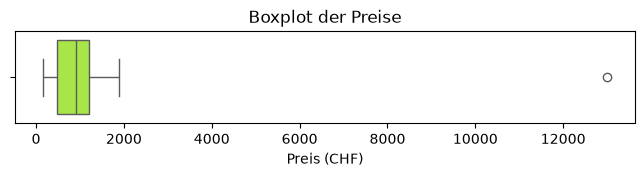

                 model                color  price_chf
107   Galaxy S25 Ultra  Titanium Silverblue    12990.0
65      Galaxy Z Fold7          Blue Shadow     1899.0
121  Pixel 10 Pro Fold                 Jade     1799.0 



,price_chf
brand,
Sony,1289.0
Google,1049.0
Apple,1024.0
Samsung,999.0
Xiaomi,719.0
OnePlus,689.0
Nothing,599.0
Fairphone,529.0
Motorola,349.0


In [5]:
# Statistical measures
print(df_clean['price_chf'].describe().round(2), '\n')

# Boxplot (seaborn)
plt.figure(figsize=(8,1.2))
sns.boxplot(x=df_clean['price_chf'], color="greenyellow")
plt.title('Boxplot der Preise', fontsize=12)
plt.xlabel('Preis (CHF)')
plt.show()

# Most expensive devices
print(df_clean[['model', 'color', 'price_chf']].sort_values(by='price_chf', ascending=False).head(3), '\n')

# Remove the data entry error (same device in another colour costs CHF 1'299)
df_B2 = df_clean.loc[(df_clean['price_chf'] != 12990)]

# Median price per brand
df_B2[['brand', 'price_chf']].groupby(['brand']).median().sort_values(by='price_chf', ascending=False)

> **Nicht Teil der Antwort** — Bezug zu Folien bzw. Übungen
>
> *Bewertung: Entscheidend ist, dass der Erfassungsfehler erkannt und begründet behandelt wird. Sowohl Sony (Median) als auch Apple (Mittelwert ohne Ausreisser) gelten als korrekt.*
>
> *Bezug: Folien Woche 4 Teil II, S. 13 («should be examined and only removed if they are errors») und S. 47–49 (`.sort_values()`, `.groupby()`); Folien Woche 5, S. 18–19 (Schiefe), S. 29–30 (Boxplot); Übung `exploratory_data_analysis_car_data_solution.ipynb` (`describe()`, Boxplot, Filtern mit `.loc[...]`).*

---
## Teil C – Python-Code schreiben (12 Punkte)

Schreiben Sie Python-Code und begründen Sie Ihre Vorgehensweise jeweils in 1–2 Sätzen. Worauf die Begründung eingehen soll, steht bei der Aufgabe.

### C1 (4 Punkte)

Die Datei `html/product_detail.html` enthält die Detailseite des Google Pixel 10 Pro. In der Code-Zelle ist bereits ein Gerüst vorgegeben, das die HTML-Datei einliest und eine Tabelle Zeile für Zeile in den Data Frame `df_C1` mit den Spalten `merkmal` und `wert` überführt.

Ergänzen Sie die beiden mit `# TODO` markierten Stellen:

1. Wählen Sie die Tabelle **«Technische Daten»** aus.
2. Entfernen Sie die Zwischenüberschriften der Tabelle (z.B. «Display») — sie sind **keine** Merkmale und dürfen im Ergebnis nicht vorkommen.

Begründen Sie, wie Sie die richtige Tabelle auswählen und die Zwischenüberschriften entfernen.

*Tipp: Öffnen Sie die HTML-Datei im Editor und sehen Sie sich `df_C1` vor dem Entfernen der Zwischenüberschriften an.*

**Begründung der Vorgehensweise:**

«Technische Daten» ist die zweite Tabelle der Seite, daher `find_all('table')[1]`. Die Zwischenüberschriften haben keine `<td>`-Zellen und ergeben leere Zeilen, die `dropna()` entfernt.

**Python-Code:**

In [6]:
# Read html from file
with open('html/product_detail.html', 'r', encoding='utf-8') as file:
    html_content = file.read()

# Parse the HTML content
soup = BeautifulSoup(html_content, 'html.parser')

# Locate the table «Technische Daten»
table = soup.find_all('table')[1]

# Extract table rows
rows = []
for row in table.find_all('tr'):
    rows.append([cell.get_text().strip() for cell in row.find_all('td')])

# Create a DataFrame
df_C1 = pd.DataFrame(rows, columns=['merkmal', 'wert'])

# Remove the sub-headings (e.g. «Display»)
df_C1 = df_C1.dropna().reset_index(drop=True)

# Show the result
df_C1

,merkmal,wert
0,Marke,Google
1,Modell,Pixel 10 Pro
2,Betriebssystem,Android 16
3,Erscheinungsdatum,28.08.2025
4,Gewicht,207 g
5,Bildschirmdiagonale,"6.3"""
6,Auflösung,1280 x 2856 Pixel
7,Bildwiederholrate,1–120 Hz
8,Akkukapazität,4'870 mAh
9,Prozessor,Google Tensor G5


> **Nicht Teil der Antwort** — Bezug zu Folien bzw. Übungen
>
> *Bezug: Übung `skipass_data.ipynb` (Read html from file, `find('table')`, `find_all('tr')`, `find_all('td')`, `get_text()`, `pd.DataFrame(rows, columns=...)`); Übung `advanced_data_preparation_car_data_solution.ipynb` (`dropna()`, `reset_index(drop=True)`).*

### C2 (4 Punkte)

Teilen Sie die Geräte in `df_clean` anhand von `price_chf` mit `pd.qcut()` in **drei ungefähr gleich grosse Preisklassen** mit den Labels `günstig`, `mittel` und `teuer` ein (neue Spalte `segment`).

Erstellen Sie anschliessend mit `pd.crosstab()` eine Kontingenztabelle mit der Anzahl Geräte pro Marke (`brand`, Zeilen) und Preisklasse (`segment`, Spalten). Begründen Sie, wie `pd.qcut()` die Klassengrenzen bestimmt und was mit den Geräten ohne Preis geschieht.

**Begründung der Vorgehensweise:**

`pd.qcut()` setzt die Grenzen über Quantile, sodass jede Klasse etwa gleich viele Geräte enthält. Geräte ohne Preis erhalten keine Klasse und werden nicht gezählt (134 statt 142).

**Python-Code:**

In [7]:
# Select columns for the analysis
df_C2 = df_clean[['brand', 'price_chf']]

# Discretization of the variable 'price_chf' into 3 bins (note the 'qcut' function)
df_C2['segment'] = pd.qcut(df_C2['price_chf'],
                           q=3,
                           labels=['günstig', 'mittel', 'teuer'])

# Contingency table
pd.crosstab(df_C2['brand'], df_C2['segment'])

segment,günstig,mittel,teuer
brand,,,
Apple,6,12,16
Fairphone,2,0,0
Google,4,8,10
Motorola,4,2,0
Nothing,4,4,0
OnePlus,4,4,0
Samsung,10,9,11
Sony,2,0,4
Xiaomi,10,5,3


> **Nicht Teil der Antwort** — Bezug zu Folien bzw. Übungen
>
> *Bezug: Übung `advanced_data_preparation_car_data_solution.ipynb` (Discretization mit `pd.qcut` und Labels); Übung `exploratory_data_analysis_car_data_solution.ipynb` (`pd.crosstab`); Folien Woche 4 Teil II, S. 26–27 (Diskretisierung) und Woche 5, S. 21–22 (Kontingenztabelle).*

### C3 (4 Punkte)

Lesen Sie die Kundenbewertungen aus `reviews.json` in einen Data Frame ein und verbinden Sie ihn mit `.merge()` über `product_id` mit `df_clean`. Berechnen Sie die **Spearman-Rangkorrelation** zwischen `price_chf` und `avg_score` (gerundet auf 2 Dezimalstellen) und erstellen Sie ein Streudiagramm (Scatter Plot) mit beschrifteten Achsen.

Begründen Sie, welche Geräte nach dem `.merge()` im Data Frame enthalten sind, und interpretieren Sie das Ergebnis in 1–2 Sätzen.

**Begründung der Vorgehensweise:**

`.merge()` behält nur Geräte, die in beiden Data Frames vorkommen — also die 124 Geräte mit Bewertung (Geräte ohne Bewertung und Bewertungen nicht mehr geführter Geräte fallen weg). Davon haben 6 keinen Preis; die Korrelation beruht daher auf 118 Geräten.

**Interpretation:** Mit 0.76 besteht ein starker positiver Zusammenhang: Teurere Geräte werden tendenziell besser bewertet. Das ist kein Beleg für Ursache und Wirkung.

**Python-Code:**

Number of rows: 124 

           price_chf  avg_score
price_chf       1.00       0.76
avg_score       0.76       1.00


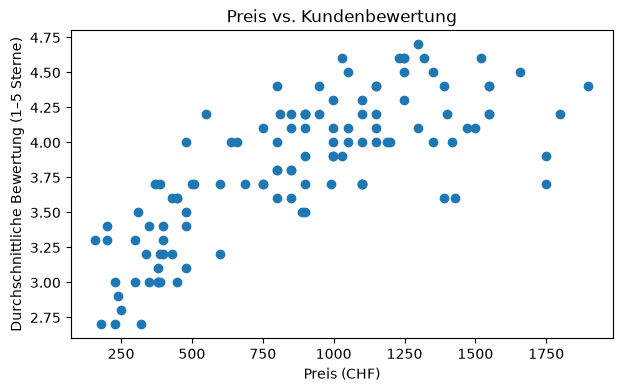

In [8]:
# Read data to a data frame using the pandas library
df_reviews = pd.read_json('reviews.json')

# Join the reviews to the shop data using .merge()
df_C3 = df_clean.merge(df_reviews, on='product_id')
print('Number of rows:', df_C3.shape[0], '\n')

# Spearman rank correlation
print(df_C3[['price_chf', 'avg_score']].corr(method='spearman').round(2))

# Exclude the data entry error of CHF 12'990 from B2 (for readability of the plot)
df_plot = df_C3.loc[(df_C3['price_chf'] != 12990)]

# Scatterplot of price and customer rating
plt.figure(figsize=(7,4))
plt.scatter(df_plot['price_chf'], df_plot['avg_score'])
plt.title('Preis vs. Kundenbewertung', fontsize=12)
plt.xlabel('Preis (CHF)')
plt.ylabel('Durchschnittliche Bewertung (1–5 Sterne)')
plt.show()

> **Nicht Teil der Antwort** — Bezug zu Folien bzw. Übungen
>
> *Bezug: Übung `input_output_and_formatting_Python.ipynb` (`pd.read_json`); Übung `advanced_data_preparation_car_data_solution.ipynb` (`.merge(..., on=...)`); Übung `exploratory_data_analysis_apartments_data.ipynb` (`.corr()`, Scatterplot); Folien Woche 5, S. 25–26 (Korrelation, Tipp `method='spearman'`), S. 37 (Scatter Plot) und S. 41 (Korrelation ≠ Kausalität).*

---
### Jupyter notebook --footer info-- (please always provide this at the end of each notebook)

In [9]:
# Libraries
import os, platform, socket
from platform import python_version
from datetime import datetime

# Print system information
print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime('%Y-%m-%d %H:%M:%S'))
print('Python Version:', python_version())
print('IP Address:', socket.gethostbyname(socket.gethostname()))
print('-----------------------------------')

-----------------------------------
POSIX
Linux | 6.8.0-1064-azure
Datetime: 2026-10-06 18:11:34
Python Version: 3.12.11
IP Address: 127.0.0.1
-----------------------------------
